# Author Info
---
Name: **Ejaz-ur-Rehman**\
Business Unit Head | Data Analyst | Crystal Tech (Project of MUZHAB Group)\
Faculty Member-Department of Management Sciences | Al Ghazali University\
MS (Finance), PhD Scholar\
Karachi, Pakistan

![Date](https://img.shields.io/badge/Date-01--August--2026-green?logo=google-calendar)
[![Email](https://img.shields.io/badge/Email-ijazfinance%40gmail.com-blue?logo=gmail)](mailto:ijazfinance@gmail.com)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Ejaz--ur--Rehman-blue?logo=linkedin)](https://www.linkedin.com/in/ejaz-ur-rehman/)
[![GitHub](https://img.shields.io/badge/GitHub-ejazurrehman-black?logo=github)](https://github.com/ejazurrehman)

# Machine Learning and Predictive Analytics for Islamic Banking

## Section-01: Introduction

### 1.1 Background

Machine Learning has become one of the most influential technologies in modern financial services. Islamic banks increasingly rely on data-driven techniques to forecast financial performance, identify growth opportunities, assess operational risks, and support strategic decision-making. Unlike traditional statistical analysis, machine learning algorithms can discover complex relationships among financial indicators and generate predictions from historical data.

The previous notebooks established the foundation for predictive analytics. The first notebook explored the dataset through exploratory data analysis (EDA), while the second notebook transformed the raw data into a cleaner and more informative dataset using feature engineering techniques. This notebook builds upon those results by applying machine learning algorithms to the engineered dataset.

### 1.2 Notebook Objectives

After completing this notebook, students will be able to:
- Understand the workflow of a machine learning project in Islamic banking.
- Convert long-format financial data into a machine learning dataset.
- Prepare predictor and target variables.
- Develop regression models for predicting financial indicators.
- Develop classification models for business decision support.
- Evaluate model performance using appropriate metrics.
- Interpret feature importance and model outputs.
- Compare different machine learning algorithms for Islamic banking applications.

### 1.3 Learning Outcomes

By the end of this notebook, students should be able to:

- Prepare financial datasets for machine learning.
- Differentiate between regression and classification problems.
- Train multiple machine learning models using Scikit-learn.
- Evaluate predictive performance using quantitative metrics.
- Explain the business implications of predictive analytics in Islamic banking.

## Section 02: Import Required Libraries

### 2.1 Purpose

This section imports all Python libraries required throughout the notebook. The libraries support data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [6]:
# ============================================================
# Machine Learning Libraries for Islamic Banking Analytics
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Regression Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 3: Load the Data Set and Prepratoin for Machine Learning

### 3.1 Load the Feature-Engineered Dataset

In [7]:
# ============================================================
# Section 2.2: Load Feature-Engineered Dataset
# ============================================================

import pandas as pd

# Load the feature-engineered dataset
df = pd.read_csv("Islamic_Banking_Feature_Engineered.csv")

print(f"Dataset Shape: {df.shape}")

display(df.head())

Dataset Shape: (85839, 19)


,Country,Regional Code,Report Type,Time Period,USD Exchange Rate,Indicator Code,Indicator Description,currency,units,Values,Values in USD Millions,Year,Quarter,Month,Month_Name,Year_Quarter,Indicator Category,Frequency,Country_Indicator_Count
0,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,AD06_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,16880.01,218.09,2013,4,10,October,2013-Q4,Other,906,136
1,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,AD07_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,603.10,7.79,2013,4,10,October,2013-Q4,Other,906,136
2,Bangladesh,SA,Islamic Banking Windows,2013-10-01,77.4,AD06_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,641.62,8.29,2013,4,10,October,2013-Q4,Other,906,136
3,Bangladesh,SA,Islamic Banking Windows,2013-10-01,77.4,AD07_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,1.08,0.01,2013,4,10,October,2013-Q4,Other,906,136
4,Bangladesh,SA,Islamic Banking,2014-01-01,77.4,AD06_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,16880.01,218.09,2014,1,1,January,2014-Q1,Other,906,136


### 3.2 Initial Data Inspection

Before preparing the machine learning dataset, it is important to verify the dataset structure, variable types, and missing values.

In [8]:
print(df.info())

display(df.describe())

display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85839 entries, 0 to 85838
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  85839 non-null  object 
 1   Regional Code            85839 non-null  object 
 2   Report Type              85839 non-null  object 
 3   Time Period              85839 non-null  object 
 4   USD Exchange Rate        85839 non-null  float64
 5   Indicator Code           85839 non-null  object 
 6   Indicator Description    85839 non-null  object 
 7   currency                 68648 non-null  object 
 8   units                    70176 non-null  object 
 9   Values                   73846 non-null  float64
 10  Values in USD Millions   73846 non-null  float64
 11  Year                     85839 non-null  int64  
 12  Quarter                  85839 non-null  int64  
 13  Month                    85839 non-null  int64  
 14  Month_Name            

,USD Exchange Rate,Values,Values in USD Millions,Year,Quarter,Month,Frequency,Country_Indicator_Count
count,85839.000000,7.384600e+04,73846.000000,85839.000000,85839.000000,85839.000000,85839.000000,85839.000000
mean,3136.032175,1.531091e+05,10233.061312,2018.978483,2.516688,5.550065,793.330596,135.400238
std,5887.339808,5.057889e+05,37268.579079,3.386500,1.122881,3.368643,453.818384,1.031853
min,3.210000,-2.584355e+04,-4236.860000,2013.000000,1.000000,1.000000,44.000000,134.000000
25%,4.050000,2.793000e+01,4.894551,2016.000000,2.000000,4.000000,453.000000,135.000000
50%,83.900000,3.457575e+03,182.635000,2019.000000,3.000000,7.000000,862.000000,135.000000
75%,280.190000,6.622165e+04,2574.160000,2022.000000,4.000000,10.000000,906.000000,136.000000
max,16421.000000,9.327270e+06,486387.800000,2025.000000,4.000000,10.000000,2265.000000,137.000000


Country                        0
Regional Code                  0
Report Type                    0
Time Period                    0
USD Exchange Rate              0
Indicator Code                 0
Indicator Description          0
currency                   17191
units                      15663
Values                     11993
Values in USD Millions     11993
Year                           0
Quarter                        0
Month                          0
Month_Name                     0
Year_Quarter                   0
Indicator Category             0
Frequency                      0
Country_Indicator_Count        0
dtype: int64

## 3.3 Interpretation

### Table-01: 

> The dataset contains 85,839 records across 19 columns (~12.4 MB), combining categorical, numeric, and time-based fields.

> Fully populated columns (no missing values): Country, Regional Code, Report Type, Time Period, USD Exchange Rate, Indicator Code, Indicator Description, Year, Quarter, Month, Month Name, Year_Quarter, Indicator Category, Frequency, and Country_Indicator_Count.

Columns with missing data:

> currency — 68,648 / 85,839 non-null (~20% missing)
> units — 70,176 / 85,839 non-null (~18% missing)
> Values — 75,185 / 85,839 non-null (~12% missing)
> Values in USD Millions — 75,185 / 85,839 non-null (~12% missing)
Data types: 3 float64, 5 int64, 11 object (string) columns.

Implication:

>The core value fields (Values, Values in USD Millions) have notable missingness (~10,600 rows each), which will need to be addressed — via imputation, filtering, or exclusion by indicator type — before these columns are used in modeling.

### Table-02:

Here is a concise breakdown of your numerical summary (df.describe()):

Time Horizon: Covers data from 2013 to 2025.

Financial Metrics (Values in USD Millions):

Range: -$4,236.86M to $486,387.8M. The negative numbers indicate net deficits or outflows.

Distribution:
> Highly right-skewed (concentrated on small values with a few extreme large values). The average ($11,297.5M) is much higher than the median ($172.9M; the middle value).

Exchange Rates (USD Exchange Rate): 
>Massive variation across currencies, ranging from 3.21 to 16,421.0 (median: 83.9).

Dataset Balance (Country_Indicator_Count): 
>Very uniform—counts per country strictly stay between 134 and 137.

### Table-03:

1. Heavy Data Skewness:

The Gap: The average (mean) value is $11,297M, but the middle value (50% / median) is only $172M.

Meaning: A few massive numbers (up to $486,387M) are pulling the average way up. You will need log transformation or scaling before running models.

2. Negative Numbers Exist:

The Lows: Values drop as low as -$4,236M.

Meaning: The dataset includes financial deficits, losses, or negative balances (not just positive revenues or GDPs).

3. Highly Balanced Data Collection:

The Numbers: Country_Indicator_Count stays tightly between 134 and 137.

Meaning: Data coverage across different countries and indicators is evenly distributed.

### 3.4 Select the Analytical Population

#### Purpose

The IFSB dataset contains multiple reporting populations, including
Islamic Banking and Islamic Banking Windows.

To ensure consistency throughout the machine learning analysis,
this notebook focuses exclusively on observations reported under
**Islamic Banking**.

Filtering the dataset at this stage ensures that each Country–Year–Quarter
combination represents a single banking population and prevents duplicate
observations during the pivot operation.

In [ ]:
# ============================================================
# Section 3.4: Select the Analytical Population
# ============================================================

print("Available Report Types\n")

display(df["Report Type"].value_counts())

# Keep only Islamic Banking observations
df = df[
    df["Report Type"] == "Islamic Banking"
].copy()

print(f"\nDataset Shape after Filtering: {df.shape}")

Available Report Types



Report Type
Islamic Banking Windows    43070
Islamic Banking            42769
Name: count, dtype: int64


Dataset Shape after Filtering: (42769, 19)


In [10]:
print(df["units"].value_counts())

units
M      27892
B       7840
n.a      908
Name: count, dtype: int64


In [11]:
# Keep only Million units
df = df[df["units"] == "M"].copy()

### 3.5 Create Unique Feature Names

In [12]:
df["Feature_Name"] = (
    df["Indicator Code"]
    + " | "
    + df["Indicator Description"]
)

### 3.6 Create the Machine Learning Dataset

In [13]:
df_ml = (
    df.pivot_table(
        index=[
            "Country",
            "Year",
            "Quarter",
            "Year_Quarter"
        ],
        columns="Feature_Name",
        values="Values",
        aggfunc="first"
    )
    .reset_index()
)

### 3.7 Verify Dataset Integrity

In [14]:
print(f"Duplicate Columns: {df_ml.columns.duplicated().sum()}")

assert df_ml.columns.duplicated().sum() == 0

print("✓ No duplicate columns found.")

Duplicate Columns: 0
✓ No duplicate columns found.


In [15]:
print(f"Machine Learning Dataset Shape: {df_ml.shape}")

display(df_ml.head())

Machine Learning Dataset Shape: (178, 169)


Feature_Name,Country,Year,Quarter,Year_Quarter,AD01_010 | Income distributed to IAH,AD01_020 | Total income from assets funded by PSIA,AD02_010 | Off-balance sheet items,AD02_020 | Total assets,AD03_010 | FX funding,AD03_020 | Total funding,...,ST07_010_0120 | Ijārah/ Ijārah Muntahia Bittamlīk/ Hire Purchase/ HPSM,ST07_010_020 | Commodity Murābahah / Tawwaruq,ST07_010_030 | Salam,ST07_010_040 | Istisnā`,ST07_010_050 | Ijārah/Ijārah Muntahia Bittamlīk,ST07_010_060 | Muḍārabah,ST07_010_070 | Mushārakah,ST07_010_080 | Diminishing Mushārakah,ST07_010_090 | Wakālah,ST08 | Assets held by domestic systemically important Islamic banks
0,Bangladesh,2013,4,2013-Q4,94346.00,120907.02,282717.45,1361995.55,23736.52,1244232.75,...,210202.13,NaN,9545.15,2781.57,NaN,19785.80,21287.40,NaN,10865.08,NaN
1,Bangladesh,2014,1,2014-Q1,94346.00,120907.02,282717.45,1361995.55,23736.52,1244232.75,...,210202.13,34.023333,9545.15,2781.57,NaN,19785.80,21287.40,1076.046667,10865.08,NaN
2,Bangladesh,2014,2,2014-Q2,96773.63,123794.31,326845.54,1499745.42,33644.32,1411437.34,...,230007.55,7567.003333,9338.39,3205.13,NaN,21438.28,19847.14,1344.720000,10698.95,NaN
3,Bangladesh,2014,3,2014-Q3,96773.63,123794.31,326845.54,1499745.42,33644.32,1411437.34,...,230007.55,7558.363333,9338.39,3205.13,NaN,21438.28,19847.14,1259.183333,10698.95,NaN
4,Bangladesh,2014,4,2014-Q4,96159.34,127986.72,306686.91,1631365.14,33170.24,1502584.82,...,251538.41,29.983333,10528.26,31319.74,NaN,27542.23,21734.08,1029.496667,9778.71,NaN


### 3.8 Define the Final Machine Learning Dataset

In [16]:
df_model = df_ml.copy()

print(f"Final Dataset Shape: {df_model.shape}")

Final Dataset Shape: (178, 169)


In [17]:
print(df_model.shape)

(178, 169)


In [18]:
print(df_model.columns.duplicated().sum())

0


In [19]:
[col for col in df_model.columns if "Total assets" in col]

['AD02_020 | Total assets',
 'CP11_020 | Total assets',
 'CP13_020 | Total assets',
 'ST03 | Total assets ']

In [20]:
display(
    df[
        df["Indicator Code"].isin(
            [
                "AD02_020",
                "CP11_020",
                "CP13_020",
                "ST03"
            ]
        )
    ][
        [
            "Indicator Code",
            "Indicator Description",
            "Indicator Category",
            "units",
            "Report Type"
        ]
    ].drop_duplicates().sort_values("Indicator Code")
)

,Indicator Code,Indicator Description,Indicator Category,units,Report Type
11702,AD02_020,Total assets,Balance Sheet,M,Islamic Banking
11700,CP11_020,Total assets,Balance Sheet,M,Islamic Banking
11701,CP13_020,Total assets,Balance Sheet,M,Islamic Banking
11916,ST03,Total assets,Balance Sheet,M,Islamic Banking


In [21]:
df[
    df["Indicator Code"].isin(
        [
            "AD02_020",
            "CP11_020",
            "CP13_020",
            "ST03"
        ]
    )
][
    [
        "Indicator Code",
        "Indicator Description",
        "Indicator Category",
        "units"
    ]
].drop_duplicates()

,Indicator Code,Indicator Description,Indicator Category,units
11700,CP11_020,Total assets,Balance Sheet,M
11701,CP13_020,Total assets,Balance Sheet,M
11702,AD02_020,Total assets,Balance Sheet,M
11916,ST03,Total assets,Balance Sheet,M


In [22]:
[col for col in df_model.columns if "Total assets" in col]

['AD02_020 | Total assets',
 'CP11_020 | Total assets',
 'CP13_020 | Total assets',
 'ST03 | Total assets ']

In [23]:
# Automatically identify all Total Assets variables

total_assets_cols = [
    col for col in df_model.columns
    if "Total assets" in col
]

display(df_model[total_assets_cols].corr())

Feature_Name,AD02_020 | Total assets,CP11_020 | Total assets,CP13_020 | Total assets,ST03 | Total assets
Feature_Name,,,,
AD02_020 | Total assets,1.000000,1.000000,1.000000,0.999794
CP11_020 | Total assets,1.000000,1.000000,1.000000,0.999794
CP13_020 | Total assets,1.000000,1.000000,1.000000,0.999794
ST03 | Total assets,0.999794,0.999794,0.999794,1.000000


In [24]:
target_regression = "AD02_020 | Total assets"

In [25]:
duplicate_target_variables = [
    "CP11_020 | Total assets",
    "CP13_020 | Total assets"
]

## Section 4: Data Transformation for Machine Learning

### 4.1 Purpose

The feature-engineered dataset currently exists in long format, where each row represents a single financial indicator for a country during a specific reporting period. While this format is suitable for data storage and exploratory analysis, it is not appropriate for most machine learning algorithms.

Machine learning models require a wide-format dataset, where each row represents a unique observation and each financial indicator becomes a separate feature (predictor). Therefore, the first step in predictive analytics is to reshape the dataset using a pivot operation.

The transformation performed in this section will:

- Convert the dataset from long format to wide format.
- Create one row for each country and reporting period.
- Convert financial indicators into independent predictor variables.
- Produce a machine learning-ready dataset for regression and classification.

### 4.2 Understanding the Transformation
Long Format (Current Dataset)
| Country  | Year_Quarter | Indicator Description  | Values |
| -------- | ------------ | ---------------------- | -----: |
| Pakistan | 2024-Q1      | Total Assets           |  8,750 |
| Pakistan | 2024-Q1      | Total Deposits         |  6,540 |
| Pakistan | 2024-Q1      | Return on Assets       |   1.12 |
| Pakistan | 2024-Q1      | Capital Adequacy Ratio |  16.30 |

Each financial indicator is stored in a separate row.

Wide Format (Machine Learning Dataset)
| Country  | Year_Quarter | Total Assets | Total Deposits |  ROA |   CAR |
| -------- | ------------ | -----------: | -------------: | ---: | ----: |
| Pakistan | 2024-Q1      |         8750 |           6540 | 1.12 | 16.30 |

Each row now represents a complete financial profile of a country for a specific reporting period.

This structure is suitable for machine learning because all predictor variables are available within a single observation.

In [26]:
# Which indicator descriptions are duplicated?

duplicate_indicators = (
    df.groupby("Indicator Description")
      .size()
      .sort_values(ascending=False)
)

display(duplicate_indicators.head(20))

Indicator Description
Total regulatory capital                                                    890
RWA                                                                         890
Tier 1 capital                                                              712
Total assets                                                                534
Others                                                                      446
(e) water supply; sewerage and waste management                             356
(g) wholesale and retail trade; repair of motor vehicles and motorcycles    356
(f)construction                                                             356
(a) agriculture, forestry, hunting and fishing                              356
(b) mining and quarrying                                                    356
(c) manufacturing                                                           356
(d) electricity, gas, steam and air-conditioning supply                     356
Diminishing Mushār

### Interpretation
The dataset exhibits uneven data availability across variables. While regulatory capital and RWA are nearly complete, several financial and sectoral financing variables have substantial missing values. Therefore, before conducting statistical analysis or machine learning, an appropriate missing data strategy (such as imputation, deletion, or variable selection) should be implemented to ensure reliable and unbiased results.

In [27]:
df[df["Indicator Description"] == "Murābahah"].head(20)

,Country,Regional Code,Report Type,Time Period,USD Exchange Rate,Indicator Code,Indicator Description,currency,units,Values,Values in USD Millions,Year,Quarter,Month,Month_Name,Year_Quarter,Indicator Category,Frequency,Country_Indicator_Count,Feature_Name
7488,Bangladesh,SA,Islamic Banking,2013-10-01,77.40,AD08_010_010,Murābahah,NC,M,85999.95,1111.11,2013,4,10,October,2013-Q4,Other,453,136,AD08_010_010 | Murābahah
7490,Bangladesh,SA,Islamic Banking,2014-01-01,77.40,AD08_010_010,Murābahah,NC,M,85999.95,1111.11,2014,1,1,January,2014-Q1,Other,453,136,AD08_010_010 | Murābahah
7492,Bangladesh,SA,Islamic Banking,2014-04-01,77.40,AD08_010_010,Murābahah,NC,M,91953.68,1188.03,2014,2,4,April,2014-Q2,Other,453,136,AD08_010_010 | Murābahah
7494,Bangladesh,SA,Islamic Banking,2014-07-01,77.40,AD08_010_010,Murābahah,NC,M,91953.68,1188.03,2014,3,7,July,2014-Q3,Other,453,136,AD08_010_010 | Murābahah
7496,Bangladesh,SA,Islamic Banking,2014-10-01,77.40,AD08_010_010,Murābahah,NC,M,93436.36,1207.19,2014,4,10,October,2014-Q4,Other,453,136,AD08_010_010 | Murābahah
7498,Bangladesh,SA,Islamic Banking,2015-01-01,77.40,AD08_010_010,Murābahah,NC,M,93436.36,1207.19,2015,1,1,January,2015-Q1,Other,453,136,AD08_010_010 | Murābahah
7500,Bangladesh,SA,Islamic Banking,2015-04-01,77.80,AD08_010_010,Murābahah,NC,M,122188.55,1570.55,2015,2,4,April,2015-Q2,Other,453,136,AD08_010_010 | Murābahah
7502,Bangladesh,SA,Islamic Banking,2015-07-01,77.80,AD08_010_010,Murābahah,NC,M,122188.55,1570.55,2015,3,7,July,2015-Q3,Other,453,136,AD08_010_010 | Murābahah
7504,Bangladesh,SA,Islamic Banking,2015-10-01,78.50,AD08_010_010,Murābahah,NC,M,69470.96,884.98,2015,4,10,October,2015-Q4,Other,453,136,AD08_010_010 | Murābahah
7506,Bangladesh,SA,Islamic Banking,2016-01-01,78.50,AD08_010_010,Murābahah,NC,M,69470.96,884.98,2016,1,1,January,2016-Q1,Other,453,136,AD08_010_010 | Murābahah


In [28]:
df[df["Indicator Description"] == "Total assets"].head(20)

,Country,Regional Code,Report Type,Time Period,USD Exchange Rate,Indicator Code,Indicator Description,currency,units,Values,Values in USD Millions,Year,Quarter,Month,Month_Name,Year_Quarter,Indicator Category,Frequency,Country_Indicator_Count,Feature_Name
11700,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,CP11_020,Total assets,NC,M,1361995.55,17596.84,2013,4,10,October,2013-Q4,Balance Sheet,1359,136,CP11_020 | Total assets
11701,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,CP13_020,Total assets,NC,M,1361995.55,17596.84,2013,4,10,October,2013-Q4,Balance Sheet,1359,136,CP13_020 | Total assets
11702,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,AD02_020,Total assets,NC,M,1361995.55,17596.84,2013,4,10,October,2013-Q4,Balance Sheet,1359,136,AD02_020 | Total assets
11706,Bangladesh,SA,Islamic Banking,2014-01-01,77.4,CP11_020,Total assets,NC,M,1361995.55,17596.84,2014,1,1,January,2014-Q1,Balance Sheet,1359,136,CP11_020 | Total assets
11707,Bangladesh,SA,Islamic Banking,2014-01-01,77.4,CP13_020,Total assets,NC,M,1361995.55,17596.84,2014,1,1,January,2014-Q1,Balance Sheet,1359,136,CP13_020 | Total assets
11708,Bangladesh,SA,Islamic Banking,2014-01-01,77.4,AD02_020,Total assets,NC,M,1361995.55,17596.84,2014,1,1,January,2014-Q1,Balance Sheet,1359,136,AD02_020 | Total assets
11712,Bangladesh,SA,Islamic Banking,2014-04-01,77.4,CP11_020,Total assets,NC,M,1499745.42,19376.56,2014,2,4,April,2014-Q2,Balance Sheet,1359,136,CP11_020 | Total assets
11713,Bangladesh,SA,Islamic Banking,2014-04-01,77.4,CP13_020,Total assets,NC,M,1499745.42,19376.56,2014,2,4,April,2014-Q2,Balance Sheet,1359,136,CP13_020 | Total assets
11714,Bangladesh,SA,Islamic Banking,2014-04-01,77.4,AD02_020,Total assets,NC,M,1499745.42,19376.56,2014,2,4,April,2014-Q2,Balance Sheet,1359,136,AD02_020 | Total assets
11718,Bangladesh,SA,Islamic Banking,2014-07-01,77.4,CP11_020,Total assets,NC,M,1499745.42,19376.56,2014,3,7,July,2014-Q3,Balance Sheet,1359,136,CP11_020 | Total assets


In [29]:
columns=["Indicator Code", "Indicator Description"]

In [30]:
print(df.columns.tolist())

['Country', 'Regional Code', 'Report Type', 'Time Period', 'USD Exchange Rate', 'Indicator Code', 'Indicator Description', 'currency', 'units', 'Values', 'Values in USD Millions', 'Year', 'Quarter', 'Month', 'Month_Name', 'Year_Quarter', 'Indicator Category', 'Frequency', 'Country_Indicator_Count', 'Feature_Name']


In [31]:
duplicate_desc = (
    df.groupby("Indicator Description")["Indicator Code"]
      .nunique()
      .sort_values(ascending=False)
)

display(duplicate_desc[duplicate_desc > 1])

Indicator Description
Total regulatory capital                                                    5
RWA                                                                         5
Tier 1 capital                                                              4
Others                                                                      3
Total assets                                                                3
(e) water supply; sewerage and waste management                             2
(g) wholesale and retail trade; repair of motor vehicles and motorcycles    2
(f)construction                                                             2
(a) agriculture, forestry, hunting and fishing                              2
(b) mining and quarrying                                                    2
(c) manufacturing                                                           2
(d) electricity, gas, steam and air-conditioning supply                     2
(j)information and communication          

In [32]:
df[df["Indicator Description"] == "Murābahah"][
    ["Indicator Code",
     "Indicator Description",
     "Indicator Category"]
].drop_duplicates()

,Indicator Code,Indicator Description,Indicator Category
7488,AD08_010_010,Murābahah,Other


In [33]:
df[df["Indicator Description"] == "Total assets"][
    ["Indicator Code",
     "Indicator Description",
     "Indicator Category"]
].drop_duplicates()

,Indicator Code,Indicator Description,Indicator Category
11700,CP11_020,Total assets,Balance Sheet
11701,CP13_020,Total assets,Balance Sheet
11702,AD02_020,Total assets,Balance Sheet


In [34]:
df["Feature_Name"] = (
    df["Indicator Code"]
    + " | "
    + df["Indicator Description"]
)

### 4.3 Create the Pivot Table

In [35]:
df_ml = (
    df.pivot_table(
        index=[
            "Country",
            "Report Type",
            "Year",
            "Quarter",
            "Year_Quarter"
        ],
        columns="Feature_Name",
        values="Values",
        aggfunc="first"
    )
    .reset_index()
)

In [36]:
df[df["Indicator Description"] == "Total assets"][
    [
        "Indicator Code",
        "Country",
        "Year_Quarter",
        "Values"
    ]
].head(20)

,Indicator Code,Country,Year_Quarter,Values
11700,CP11_020,Bangladesh,2013-Q4,1361995.55
11701,CP13_020,Bangladesh,2013-Q4,1361995.55
11702,AD02_020,Bangladesh,2013-Q4,1361995.55
11706,CP11_020,Bangladesh,2014-Q1,1361995.55
11707,CP13_020,Bangladesh,2014-Q1,1361995.55
11708,AD02_020,Bangladesh,2014-Q1,1361995.55
11712,CP11_020,Bangladesh,2014-Q2,1499745.42
11713,CP13_020,Bangladesh,2014-Q2,1499745.42
11714,AD02_020,Bangladesh,2014-Q2,1499745.42
11718,CP11_020,Bangladesh,2014-Q3,1499745.42


In [37]:
duplicate_rows = (
    df.groupby(
        [
            "Country",
            "Year_Quarter",
            "Indicator Code"
        ]
    )
    .size()
    .sort_values(ascending=False)
)

display(duplicate_rows[duplicate_rows > 1].head(20))

Series([], dtype: int64)

In [38]:
df[
    (df["Country"] == "Bangladesh") &
    (df["Year_Quarter"] == "2013-Q4") &
    (df["Indicator Code"] == "AD02_020")
].sort_values("Report Type")

,Country,Regional Code,Report Type,Time Period,USD Exchange Rate,Indicator Code,Indicator Description,currency,units,Values,Values in USD Millions,Year,Quarter,Month,Month_Name,Year_Quarter,Indicator Category,Frequency,Country_Indicator_Count,Feature_Name
11702,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,AD02_020,Total assets,NC,M,1361995.55,17596.84,2013,4,10,October,2013-Q4,Balance Sheet,1359,136,AD02_020 | Total assets


### 4.4 Inspect the New Dataset

#### 4.4.1 Display First Five Records

In [39]:
df_ml.head()

Feature_Name,Country,Report Type,Year,Quarter,Year_Quarter,AD01_010 | Income distributed to IAH,AD01_020 | Total income from assets funded by PSIA,AD02_010 | Off-balance sheet items,AD02_020 | Total assets,AD03_010 | FX funding,...,ST07_010_0120 | Ijārah/ Ijārah Muntahia Bittamlīk/ Hire Purchase/ HPSM,ST07_010_020 | Commodity Murābahah / Tawwaruq,ST07_010_030 | Salam,ST07_010_040 | Istisnā`,ST07_010_050 | Ijārah/Ijārah Muntahia Bittamlīk,ST07_010_060 | Muḍārabah,ST07_010_070 | Mushārakah,ST07_010_080 | Diminishing Mushārakah,ST07_010_090 | Wakālah,ST08 | Assets held by domestic systemically important Islamic banks
0,Bangladesh,Islamic Banking,2013,4,2013-Q4,94346.00,120907.02,282717.45,1361995.55,23736.52,...,210202.13,NaN,9545.15,2781.57,NaN,19785.80,21287.40,NaN,10865.08,NaN
1,Bangladesh,Islamic Banking,2014,1,2014-Q1,94346.00,120907.02,282717.45,1361995.55,23736.52,...,210202.13,34.023333,9545.15,2781.57,NaN,19785.80,21287.40,1076.046667,10865.08,NaN
2,Bangladesh,Islamic Banking,2014,2,2014-Q2,96773.63,123794.31,326845.54,1499745.42,33644.32,...,230007.55,7567.003333,9338.39,3205.13,NaN,21438.28,19847.14,1344.720000,10698.95,NaN
3,Bangladesh,Islamic Banking,2014,3,2014-Q3,96773.63,123794.31,326845.54,1499745.42,33644.32,...,230007.55,7558.363333,9338.39,3205.13,NaN,21438.28,19847.14,1259.183333,10698.95,NaN
4,Bangladesh,Islamic Banking,2014,4,2014-Q4,96159.34,127986.72,306686.91,1631365.14,33170.24,...,251538.41,29.983333,10528.26,31319.74,NaN,27542.23,21734.08,1029.496667,9778.71,NaN


#### 4.4.2 Check Dataset Dimensions

In [40]:
print(f"Rows    : {df_ml.shape[0]:,}")
print(f"Columns : {df_ml.shape[1]}")

Rows    : 178
Columns : 170


#### 4.4.3 Check Variable Types

In [41]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Columns: 170 entries, Country to ST08 | Assets held by domestic systemically important Islamic banks
dtypes: float64(165), int64(2), object(3)
memory usage: 236.5+ KB


#### 4.4.4 Display Variable Names

In [42]:
df_ml.columns.tolist()

['Country',
 'Report Type',
 'Year',
 'Quarter',
 'Year_Quarter',
 'AD01_010 | Income distributed to IAH',
 'AD01_020 | Total income from assets funded by PSIA',
 'AD02_010 | Off-balance sheet items',
 'AD02_020 | Total assets',
 'AD03_010 | FX funding ',
 'AD03_020 | Total funding',
 'AD04_010 | FX financing',
 'AD04_020 | Total financing',
 'AD05_010 | Sukūk holdings',
 'AD05_020 | Total regulatory capital',
 'AD06_010 | Value of Sharī`ah-compliant financing',
 'AD06_010_010 | Sectoral distribution',
 'AD06_010_010_010 | (a) agriculture, forestry, hunting and fishing',
 'AD06_010_010_0110 | (i)accommodation and food service activities',
 'AD06_010_010_0130 | (j)information and communication',
 'AD06_010_010_0140 | (k) financial and insurance activities ',
 'AD06_010_010_0150 | (l)real estate activities',
 'AD06_010_010_0170 | (m)  professional, scientific and technical activities',
 'AD06_010_010_0180 | (n) administrative and support service activities',
 'AD06_010_010_0190 | (o) pub

### 4.5 Verify the Transformation

The following checks confirm that the transformation has been performed correctly.

#### 4.5.1 Check for Duplicate Observations

In [43]:
duplicates = df_ml.duplicated().sum()

print(f"Duplicate rows : {duplicates}")

Duplicate rows : 0


#### 4.5.2 Check Missing Values

In [44]:
missing = (
    df_ml
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Feature_Name
ST08 | Assets held by domestic systemically important Islamic banks                      151
AD08 | Value (or percentage) of returns by major type of Sharī`ah-compliant contract     150
AD08_010_0110_020 | (ii)                                                                 147
AD07_010_010 | Economic activity                                                         146
AD06_010_010 | Sectoral distribution                                                     146
                                                                                        ... 
AD07_010_010_0200 | (p) education                                                          1
ST07_010_0110 | Others                                                                     1
ST07_010_030 | Salam                                                                       1
AD06_010_010_0210 | (p) education                                                          1
ST07_010_0100 | Qarḍ Hassan                              

#### 4.5.3 Summary Statistics

In [45]:
df_ml.describe().T

,count,mean,std,min,25%,50%,75%,max
Feature_Name,,,,,,,,
Year,178.0,2018.887640,3.354525,2013.00,2016.0000,2019.000,2022.0000,2025.00
Quarter,178.0,2.516854,1.126089,1.00,2.0000,3.000,4.0000,4.00
AD01_010 | Income distributed to IAH,106.0,60114.920189,67450.912886,259.85,731.3450,34333.525,96440.5900,369322.50
AD01_020 | Total income from assets funded by PSIA,106.0,89642.999245,97639.557521,355.84,1285.5000,67389.280,141498.9700,553841.90
AD02_010 | Off-balance sheet items,178.0,495082.511517,545848.947246,40933.00,143817.3325,326845.540,577268.7550,2661074.85
...,...,...,...,...,...,...,...,...
ST07_010_060 | Muḍārabah,178.0,7080.426517,15406.612493,0.00,0.0000,127.190,914.3725,65034.65
ST07_010_070 | Mushārakah,178.0,82763.566292,136712.656270,1077.37,5055.4775,26785.330,76028.3275,818988.46
ST07_010_080 | Diminishing Mushārakah,176.0,100906.448807,214118.604155,0.00,0.0000,0.000,90490.0675,1096379.54


### 4.6 Save the Machine Learning Dataset

The transformed dataset will be used throughout the remainder of the notebook.

In [46]:
df_ml.to_csv(
    "Islamic_Banking_ML_Dataset.csv",
    index=False
)

print("Machine learning dataset saved successfully.")

Machine learning dataset saved successfully.


## Interpretation

The dataset has now been transformed into a machine learning-ready structure. Each row represents a unique country during a specific reporting period, while each column represents a financial indicator that can serve as a predictor in subsequent models.

The pivot transformation has introduced missing values because not every country reports every financial indicator in every reporting period. Before developing predictive models, these missing values must be carefully examined and treated. The next section focuses on data preparation for machine learning, including missing value analysis, feature selection, and data quality assessment.

## Section 5: Data Preparation for Machine Learning

### 5.1 Purpose

The machine learning dataset created in the previous section contains one observation for each country and reporting period. However, the transformation from long format to wide format introduced missing values because not every financial indicator is reported by every country during every reporting period.

Before building predictive models, it is essential to evaluate the quality of the transformed dataset. This section focuses on identifying missing values, selecting an appropriate treatment strategy, removing variables with excessive missingness, and verifying that the final dataset is suitable for machine learning.

By the end of this section, the dataset will be fully prepared for feature selection and predictive modeling.

### 5.2 Overview of Missing Values

The first step is to identify variables containing missing observations.

In [47]:
# ============================================================
# Missing Values Summary
# ============================================================

missing_count = (
    df_ml
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_count = missing_count[missing_count > 0]

print(f"Variables with missing values: {len(missing_count)}")

missing_count

Variables with missing values: 96


Feature_Name
ST08 | Assets held by domestic systemically important Islamic banks                      151
AD08 | Value (or percentage) of returns by major type of Sharī`ah-compliant contract     150
AD08_010_0110_020 | (ii)                                                                 147
AD07_010_010 | Economic activity                                                         146
AD06_010_010 | Sectoral distribution                                                     146
                                                                                        ... 
AD07_010_010_0200 | (p) education                                                          1
ST07_010_0110 | Others                                                                     1
ST07_010_030 | Salam                                                                       1
AD06_010_010_0210 | (p) education                                                          1
ST07_010_0100 | Qarḍ Hassan                              

### Interpretation

The output displays the number of missing observations for each variable. These missing values are expected because several financial indicators are reported only by selected countries or during specific reporting periods. Therefore, missing values at this stage do not necessarily indicate data quality issues but rather differences in reporting practices across jurisdictions.

### 5.3 Missing Value Percentage

Absolute counts alone do not fully describe the extent of missingness. Calculating the percentage of missing observations provides a more meaningful basis for deciding whether a variable should be retained, imputed, or removed.

In [48]:
# ============================================================
# Missing Percentage
# ============================================================

missing_percent = (
    df_ml
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent = missing_percent[missing_percent > 0]

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent.round(2)
})

missing_summary

,Missing Count,Missing Percentage
Feature_Name,,
ST08 | Assets held by domestic systemically important Islamic banks,151,84.83
AD08 | Value (or percentage) of returns by major type of Sharī`ah-compliant contract,150,84.27
AD08_010_0110_020 | (ii),147,82.58
AD07_010_010 | Economic activity,146,82.02
AD06_010_010 | Sectoral distribution,146,82.02
...,...,...
AD07_010_010_0200 | (p) education,1,0.56
ST07_010_0110 | Others,1,0.56
ST07_010_030 | Salam,1,0.56


### 5.4 Visualizing Missing Values

A graphical representation helps identify variables with substantial missingness.

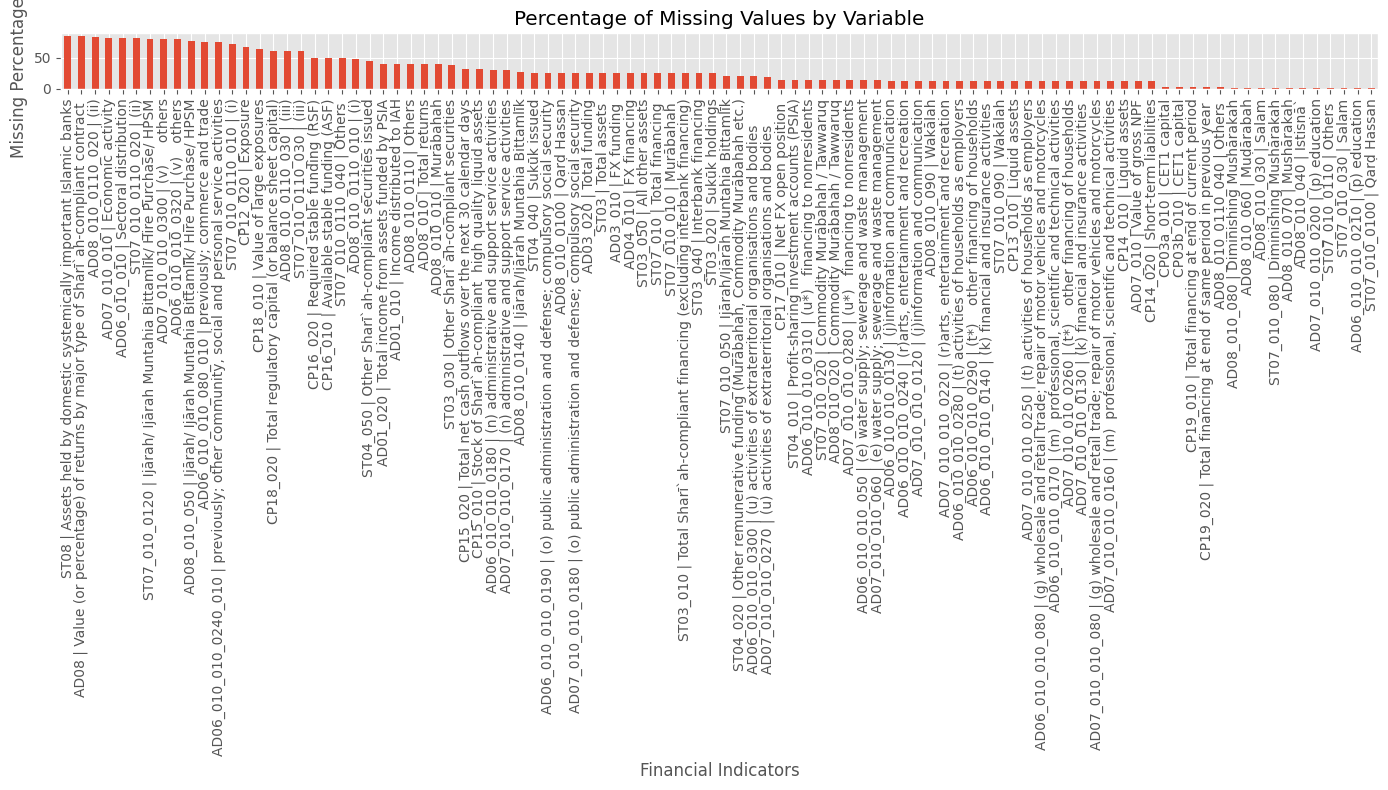

In [49]:
# ============================================================
# Missing Value Percentage
# ============================================================

plt.figure(figsize=(14,8))

missing_summary["Missing Percentage"].plot(kind="bar")

plt.title("Percentage of Missing Values by Variable")
plt.xlabel("Financial Indicators")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### 5.5 Missing Value Treatment Strategy

Before applying any treatment, a clear decision rule is required. The following framework will be used throughout this notebook.
| Missing Percentage | Treatment Strategy                                    |
| -----------------: | ----------------------------------------------------- |
|                 0% | Retain variable                                       |
|       Less than 5% | Median imputation                                     |
|          5% to 30% | Evaluate business importance, then impute if retained |
|         30% to 70% | Retain only if financially significant                |
|   Greater than 70% | Remove from the dataset                               |

**NOTE**: This framework balances statistical quality with the practical relevance of financial indicators.

### 5.6 Remove Variables with Excessive Missing Values

Variables containing more than 70% missing observations contribute limited information and may adversely affect model performance. Such variables will therefore be removed.

In [50]:
# ============================================================
# Remove Variables with High Missingness
# ============================================================

threshold = 70

columns_to_drop = missing_percent[
    missing_percent > threshold
].index

print("Variables to be removed:")
print(columns_to_drop.tolist())

df_ml_clean = df_ml.drop(columns=columns_to_drop)

print(f"\nVariables removed : {len(columns_to_drop)}")
print(f"Remaining columns : {df_ml_clean.shape[1]}")

Variables to be removed:
['ST08 | Assets held by domestic systemically important Islamic banks', 'AD08 | Value (or percentage) of returns by major type of Sharī`ah-compliant contract ', 'AD08_010_0110_020 | (ii)', 'AD07_010_010 | Economic activity', 'AD06_010_010 | Sectoral distribution', 'ST07_010_0110_020 | (ii)', 'ST07_010_0120 | Ijārah/ Ijārah Muntahia Bittamlīk/ Hire Purchase/ HPSM', 'AD07_010_010_0300 | (v)     others', 'AD06_010_010_0320 | (v)   others', 'AD08_010_050 | Ijārah/ Ijārah Muntahia Bittamlīk/ Hire Purchase/ HPSM', 'AD06_010_010_080_010 | previously; commerce and trade', 'AD06_010_010_0240_010 | previously; other community, social and personal service activities', 'ST07_010_0110_010 | (i)']

Variables removed : 13
Remaining columns : 157


### 5.7 Impute Remaining Missing Values

After removing variables with excessive missingness, the remaining numerical variables are imputed using the median. Median imputation is appropriate because it is robust to extreme values that are common in financial datasets.

In [51]:
# ============================================================
# Median Imputation
# ============================================================

numeric_columns = df_ml_clean.select_dtypes(include=["number"]).columns

df_ml_clean[numeric_columns] = (
    df_ml_clean[numeric_columns]
    .fillna(df_ml_clean[numeric_columns].median())
)

print("Missing values have been imputed using the median.")

Missing values have been imputed using the median.


### 5.8 Verify Data Quality

The final verification confirms that the dataset is complete and ready for predictive modeling.

In [52]:
# ============================================================
# Final Missing Value Check
# ============================================================

remaining_missing = df_ml_clean.isnull().sum().sum()

print(f"Remaining missing values: {remaining_missing}")

Remaining missing values: 0


#### 5.8.1 Display Dataset Information

In [53]:
df_ml_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Columns: 157 entries, Country to ST07_010_090 | Wakālah
dtypes: float64(152), int64(2), object(3)
memory usage: 218.5+ KB


#### 5.8.2 Display Dataset Shape

In [54]:
print(f"Rows    : {df_ml_clean.shape[0]:,}")
print(f"Columns : {df_ml_clean.shape[1]}")

Rows    : 178
Columns : 157


### 5.9 Save the Clean Machine Learning Dataset

The cleaned dataset will be used throughout the remainder of the notebook.

In [55]:
# ============================================================
# Save Clean Machine Learning Dataset
# ============================================================

df_ml_clean.to_csv(
    "Islamic_Banking_ML_Clean.csv",
    index=False
)

print("Clean machine learning dataset saved successfully.")

Clean machine learning dataset saved successfully.


## Interpretation

The machine learning dataset has now been cleaned and prepared for predictive analytics. Variables with excessive missing values were removed, while the remaining numerical variables were completed using median imputation. These preprocessing steps improve data quality and ensure that machine learning algorithms can be trained without interruptions caused by incomplete observations.

The resulting dataset provides a reliable foundation for model development while preserving the most informative financial indicators.

## Section 6: Feature Selection and Target Variable Identification

### 6.1 Purpose

Feature selection is a critical step in the machine learning pipeline. Although the cleaned dataset contains numerous financial indicators, not every variable should be included in predictive modeling. Some variables serve only as identifiers, while others may introduce redundancy or target leakage, leading to overly optimistic model performance.

This section aims to identify informative predictor variables and establish suitable target variables for both regression and classification. The resulting feature set will provide a reliable foundation for developing predictive models in the following sections.

### 6.2 Understanding Predictor and Target Variables

In supervised machine learning, the dataset is divided into two components:

- Predictor variables (X): Independent variables used by the model to learn patterns.
- Target variable (y): The outcome that the model attempts to predict.

For this notebook:

- Regression: Predict a continuous financial indicator.
- Classification: Predict a categorical banking class derived from financial data.

### 6.3 Review Available Variables

Before selecting predictors, review the variables available in the cleaned dataset.

In [56]:
# ============================================================
# Review Variables
# ============================================================

print(f"Total Variables : {len(df_ml_clean.columns)}")

for column in df_ml_clean.columns:
    print(column)

Total Variables : 157
Country
Report Type
Year
Quarter
Year_Quarter
AD01_010 | Income distributed to IAH
AD01_020 | Total income from assets funded by PSIA
AD02_010 | Off-balance sheet items
AD02_020 | Total assets
AD03_010 | FX funding 
AD03_020 | Total funding
AD04_010 | FX financing
AD04_020 | Total financing
AD05_010 | Sukūk holdings
AD05_020 | Total regulatory capital
AD06_010 | Value of Sharī`ah-compliant financing
AD06_010_010_010 | (a) agriculture, forestry, hunting and fishing
AD06_010_010_0110 | (i)accommodation and food service activities
AD06_010_010_0130 | (j)information and communication
AD06_010_010_0140 | (k) financial and insurance activities 
AD06_010_010_0150 | (l)real estate activities
AD06_010_010_0170 | (m)  professional, scientific and technical activities
AD06_010_010_0180 | (n) administrative and support service activities
AD06_010_010_0190 | (o) public administration and defense; compulsory social security
AD06_010_010_020 | (b) mining and quarrying
AD06_010_0

### 6.4 Remove Identifier Variables

Several variables uniquely identify an observation but contain no predictive information. These variables should not be used as model inputs.

In [57]:
# ============================================================
# Identifier Variables
# ============================================================

identifier_columns = [
    "Country",
    "Year",
    "Quarter",
    "Year_Quarter"
]

df_model = df_ml_clean.copy()

print("Identifier variables identified.")
print(identifier_columns)

Identifier variables identified.
['Country', 'Year', 'Quarter', 'Year_Quarter']


> Note: These variables will remain in the dataset for reporting and interpretation but will be excluded from the feature matrix (X).

### 6.5 Detect Highly Correlated Variables

Highly correlated variables may provide duplicate information and increase multicollinearity, particularly in regression models.

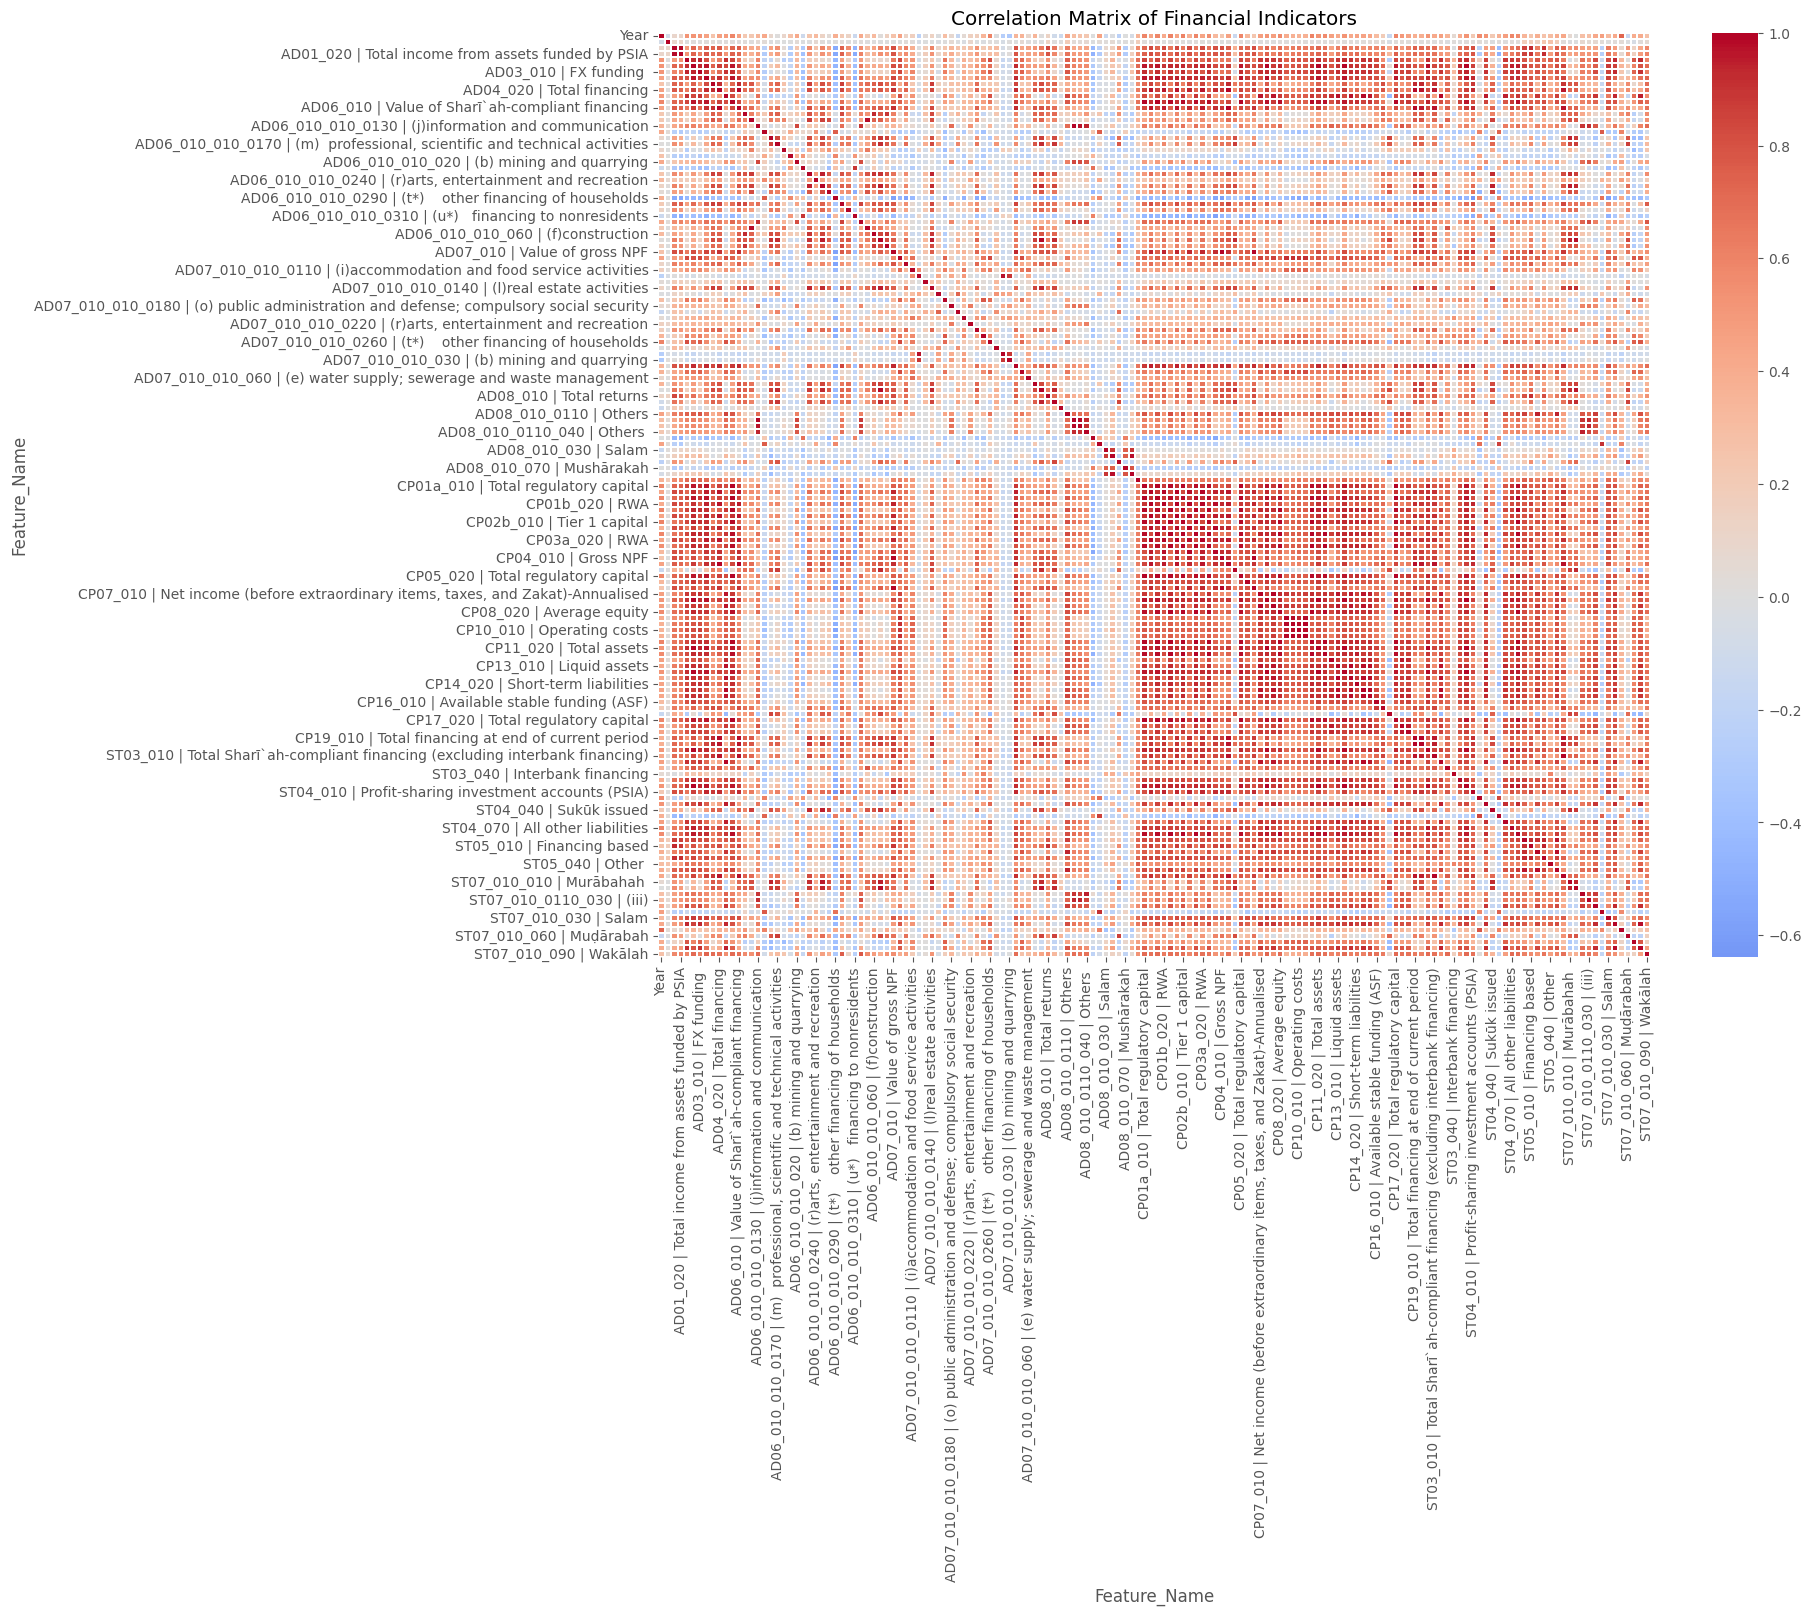

In [58]:
# ============================================================
# Correlation Matrix
# ============================================================

numeric_df = df_model.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Financial Indicators")
plt.show()

### 6.6 Identify Highly Correlated Pairs

To simplify interpretation, identify variable pairs with an absolute correlation greater than 0.90.

In [59]:
print(df_model.columns.name)

Feature_Name


In [60]:
# Remove the column index name left by pivot_table()
df_model.columns.name = None

In [61]:
# ============================================================
# Highly Correlated Variable Pairs
# ============================================================

# Remove the column index name if it exists
correlation_matrix.columns.name = None
correlation_matrix.index.name = None

high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        corr = correlation_matrix.iloc[i, j]

        if abs(corr) >= 0.90:
            high_corr_pairs.append([
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                round(corr, 3)
            ])

high_corr = pd.DataFrame(
    high_corr_pairs,
    columns=[
        "Variable 1",
        "Variable 2",
        "Correlation"
    ]
)

high_corr = high_corr.sort_values(
    by="Correlation",
    ascending=False
)

high_corr.head(20)

,Variable 1,Variable 2,Correlation
37,AD02_020 | Total assets,CP13_020 | Total assets,1.0
325,CP02a_010 | Tier 1 capital,CP11_010 | Tier 1 capital,1.0
271,CP01a_020 | Risk-weighted assets (RWA),CP03a_020 | RWA,1.0
34,AD02_020 | Total assets,CP11_020 | Total assets,1.0
535,CP11_020 | Total assets,ST04 | Total funding/liabilities and equities,1.0
529,CP11_020 | Total assets,CP13_020 | Total assets,1.0
513,CP09_020 | Gross income,CP10_020 | Gross income,1.0
317,CP02a_010 | Tier 1 capital,CP02b_010 | Tier 1 capital,1.0
292,CP01b_010 | Total regulatory capital,CP05_020 | Total regulatory capital,1.0
361,CP02b_010 | Tier 1 capital,CP11_010 | Tier 1 capital,1.0


### Interpretation

A high correlation between two predictors indicates that they contain similar information. During model development, only one of the variables may be retained to reduce redundancy and improve interpretability. However, removal should also consider financial relevance rather than relying solely on statistical thresholds.

### 6.7 Data Integrity Check

#### 6.7.1 Identify Duplicate Columns

In [62]:
# ============================================================
# Identify Duplicate Column Names
# ============================================================

duplicate_columns = df_model.columns[df_model.columns.duplicated()]

print(f"Duplicate columns found: {len(duplicate_columns)}")
print(duplicate_columns.tolist())

Duplicate columns found: 0
[]


#### 6.6.2 Investigate Duplicate Columns

Before removing them, compare whether the duplicate columns contain identical values.

In [63]:
# ============================================================
# Compare Duplicate Columns
# ============================================================

duplicates = duplicate_columns.unique()

for col in duplicates:

    duplicate_df = df_model.loc[:, df_model.columns == col]

    print(f"\nColumn: {col}")
    print(f"Occurrences: {duplicate_df.shape[1]}")

    if duplicate_df.shape[1] == 2:
        identical = duplicate_df.iloc[:, 0].equals(duplicate_df.iloc[:, 1])
        print(f"Identical values: {identical}")

#### 6.7.3 Remove Duplicate Columns

If the duplicates are confirmed to be identical, retain the first occurrence.

In [64]:
# ============================================================
# Remove Duplicate Columns
# ============================================================

df_model = df_model.loc[:, ~df_model.columns.duplicated()]

print("Duplicate columns removed.")
print(f"Remaining variables: {df_model.shape[1]}")

Duplicate columns removed.
Remaining variables: 157


#### 6.7.4 Verify Data Integrity

In [65]:
duplicate_columns = df_model.columns[df_model.columns.duplicated()]

print("Remaining duplicate columns:")
print(duplicate_columns.tolist())

Remaining duplicate columns:
[]


### 6.7 Selection of Target Variables
Purpose

The objective of supervised machine learning is to predict an outcome variable using a set of explanatory variables. Therefore, selecting an appropriate target variable is one of the most important decisions in model development.

This notebook demonstrates both regression and classification using the same Islamic banking dataset. Consequently, two target variables will be prepared:

- A continuous target for regression.
- A categorical target for classification.

Before selecting these targets, it is important to avoid target leakage, where predictor variables contain direct information about the target variable, resulting in unrealistically high prediction accuracy.

#### 6.7.1 Define the Regression Target

Following the data integrity checks, Total assets is selected as the regression target because it is a continuous financial indicator that reflects the overall size of the Islamic banking sector and is widely used in banking analysis.

In [66]:
# ============================================================
# Define Regression Target
# ============================================================

target_regression = "Total assets"

print("Regression Target:")
print(target_regression)

Regression Target:
Total assets


In [67]:
# ============================================================
# Notebook Configuration
# ============================================================

TARGET_REGRESSION = "AD02_020 | Total assets"

print("Regression Target:", TARGET_REGRESSION)

assert TARGET_REGRESSION in df_model.columns, \
    f"{TARGET_REGRESSION} not found in df_model."

Regression Target: AD02_020 | Total assets


In [68]:
target_regression = TARGET_REGRESSION

## Section 7: Regression Modeling

### 7.1 Purpose of Regression Modeling

Regression modeling is one of the most widely used supervised machine learning techniques for predicting continuous numerical values. Unlike classification models, which assign observations to predefined categories, regression models estimate the actual magnitude of a target variable based on a set of explanatory features.

In the context of Islamic banking, predicting a bank's Total Assets is a valuable analytical task because it provides insights into institutional growth, financial stability, and operational performance. By learning the relationships between financial indicators and total assets, regression models can assist researchers, analysts, and decision-makers in forecasting future asset values and identifying the factors that contribute most to bank performance.

In this notebook, Total Assets has been selected as the regression target variable. The feature-engineered dataset prepared in Notebook 02 will serve as the input for building predictive models. The regression workflow begins with a baseline Linear Regression model, followed by more advanced machine learning algorithms in the next section.

Throughout this process, the notebook follows the standard machine learning pipeline, including data preparation, train-test splitting, feature scaling, model training, model evaluation, visualization, and interpretation of results. This structured approach promotes reproducibility and reflects best practices in financial data analytics.

# 7.2 Prepare the Regression Dataset

## Purpose

Before developing a regression model, the predictor variables (**X**) and the target variable (**y**) must be clearly defined.

In this notebook, the regression target is **AD02_020 | Total assets**, which represents the Total Assets indicator selected from the IFSB dataset.

During data validation, several variables representing alternative forms of Total Assets were identified. Two of these variables (**CP11_020 | Total assets** and **CP13_020 | Total assets**) were found to be perfectly correlated with the selected target variable. Including them as predictors would introduce perfect multicollinearity and result in data leakage.

Therefore, these redundant variables are removed from the predictor matrix.

Additionally, identifier variables such as Country and Year_Quarter are preserved separately for reporting purposes but are excluded from model training because they do not represent numerical financial characteristics.

At the end of this section, the machine learning dataset is divided into:

- **X_reg** : Predictor variables
- **y_reg** : Regression target variable

These datasets will be used throughout the regression modelling process.

In [69]:
# ============================================================
# Define Regression Target
# ============================================================

target_regression = "AD02_020 | Total assets"

print("Regression Target:")
print(target_regression)

Regression Target:
AD02_020 | Total assets


In [70]:
# ============================================================
# Verify Target Availability
# ============================================================

if target_regression in df_model.columns:
    print(f"✓ '{target_regression}' found successfully.")
else:
    raise ValueError(
        f"Target variable '{target_regression}' was not found."
    )

✓ 'AD02_020 | Total assets' found successfully.


In [71]:
# ============================================================
# Section 7.2: Prepare Regression Dataset
# ============================================================

# ------------------------------------------------------------
# Define the regression target
# ------------------------------------------------------------

target_regression = "AD02_020 | Total assets"

# ------------------------------------------------------------
# Preserve observation information
# (Required later for prediction reports)
# ------------------------------------------------------------

observation_info = df_model[
    [
        "Country",
        "Year_Quarter"
    ]
].copy()

# ------------------------------------------------------------
# Perfectly correlated variables
# (Remove to avoid multicollinearity)
# ------------------------------------------------------------

duplicate_target_variables = [
    "CP11_020 | Total assets",
    "CP13_020 | Total assets"
]

# ------------------------------------------------------------
# Identifier columns
# ------------------------------------------------------------

identifier_columns = [
    "Country",
    "Report Type",
    "Year",
    "Quarter",
    "Year_Quarter"
]

# ------------------------------------------------------------
# Columns excluded from regression predictors
# ------------------------------------------------------------

columns_to_exclude_reg = (
    identifier_columns
    + [target_regression]
    + duplicate_target_variables
)

# ------------------------------------------------------------
# Create predictor matrix (X)
# ------------------------------------------------------------

X_reg = df_model.drop(
    columns=columns_to_exclude_reg,
    errors="ignore"
)

# ------------------------------------------------------------
# Create regression target (y)
# ------------------------------------------------------------

y_reg = df_model[target_regression]

# ------------------------------------------------------------
# Display dataset summary
# ------------------------------------------------------------

print("=" * 65)
print("Regression Dataset Summary")
print("=" * 65)

print(f"Regression Target : {target_regression}")

print("\nPredictor Matrix Shape")
print(X_reg.shape)

print("\nTarget Variable Shape")
print(y_reg.shape)

print("\nObservation Information Shape")
print(observation_info.shape)

print("\nRemoved Variables")

for col in columns_to_exclude_reg:
    print(f"• {col}")

Regression Dataset Summary
Regression Target : AD02_020 | Total assets

Predictor Matrix Shape
(178, 149)

Target Variable Shape
(178,)

Observation Information Shape
(178, 2)

Removed Variables
• Country
• Report Type
• Year
• Quarter
• Year_Quarter
• AD02_020 | Total assets
• CP11_020 | Total assets
• CP13_020 | Total assets


In [72]:
# ============================================================
# Verify Regression Dataset
# ============================================================

print("Predictor Variables")

display(X_reg.head())

print("\nTarget Variable")

display(y_reg.head())

print("\nObservation Information")

display(observation_info.head())

Predictor Variables


,AD01_010 | Income distributed to IAH,AD01_020 | Total income from assets funded by PSIA,AD02_010 | Off-balance sheet items,AD03_010 | FX funding,AD03_020 | Total funding,AD04_010 | FX financing,AD04_020 | Total financing,AD05_010 | Sukūk holdings,AD05_020 | Total regulatory capital,AD06_010 | Value of Sharī`ah-compliant financing,...,ST07_010_0110_030 | (iii),ST07_010_0110_040 | Others,ST07_010_020 | Commodity Murābahah / Tawwaruq,ST07_010_030 | Salam,ST07_010_040 | Istisnā`,ST07_010_050 | Ijārah/Ijārah Muntahia Bittamlīk,ST07_010_060 | Muḍārabah,ST07_010_070 | Mushārakah,ST07_010_080 | Diminishing Mushārakah,ST07_010_090 | Wakālah
0,94346.00,120907.02,282717.45,23736.52,1244232.75,46747.28,1038880.72,95440.98,107775.73,1038880.72,...,4339.99,61033.840000,17543.679231,9545.15,2781.57,78901.065,19785.80,21287.40,0.000000,10865.08
1,94346.00,120907.02,282717.45,23736.52,1244232.75,46747.28,1038880.72,95440.98,107775.73,1038880.72,...,4339.99,61033.840000,34.023333,9545.15,2781.57,78901.065,19785.80,21287.40,1076.046667,10865.08
2,96773.63,123794.31,326845.54,33644.32,1411437.34,42689.73,1160209.61,119392.29,110287.03,1160209.61,...,4339.99,97470.260000,7567.003333,9338.39,3205.13,78901.065,21438.28,19847.14,1344.720000,10698.95
3,96773.63,123794.31,326845.54,33644.32,1411437.34,42689.73,1160209.61,119392.29,110287.03,1160209.61,...,4339.99,97470.260000,7558.363333,9338.39,3205.13,78901.065,21438.28,19847.14,1259.183333,10698.95
4,96159.34,127986.72,306686.91,33170.24,1502584.82,51937.91,1265833.61,137905.03,120748.80,1265833.61,...,4339.99,88403.216667,29.983333,10528.26,31319.74,78901.065,27542.23,21734.08,1029.496667,9778.71



Target Variable


0    1361995.55
1    1361995.55
2    1499745.42
3    1499745.42
4    1631365.14
Name: AD02_020 | Total assets, dtype: float64


Observation Information


,Country,Year_Quarter
0,Bangladesh,2013-Q4
1,Bangladesh,2014-Q1
2,Bangladesh,2014-Q2
3,Bangladesh,2014-Q3
4,Bangladesh,2014-Q4


In [73]:
# ============================================================
# Regression Dataset Validation
# ============================================================

print("=" * 65)
print("Regression Dataset Validation")
print("=" * 65)

print(f"X_reg Shape : {X_reg.shape}")
print(f"y_reg Shape : {y_reg.shape}")

print("\nNon-Numeric Columns")

display(
    X_reg.select_dtypes(include="object").columns
)

print("\nMissing Values")

print(X_reg.isnull().sum().sum())

print("\nDuplicate Columns")

print(X_reg.columns.duplicated().sum())

Regression Dataset Validation
X_reg Shape : (178, 149)
y_reg Shape : (178,)

Non-Numeric Columns


Index([], dtype='object')


Missing Values
0

Duplicate Columns
0


### Interpretation

The regression dataset has been successfully prepared.

The predictor matrix (**X_reg**) contains only numerical financial indicators suitable for machine learning.

The regression target (**y_reg**) contains the selected Total Assets variable.

Perfectly correlated variables were excluded to prevent multicollinearity and target leakage.

Furthermore, all identifier variables have been removed from the predictor matrix while being preserved separately for future prediction reports.

The dataset is now ready to be partitioned into training and testing subsets.

### Next Step

With the regression dataset prepared, the next step is to divide the data into training and testing subsets. This enables the model to learn from one portion of the data while being evaluated on previously unseen observations.

The train-test split will be implemented in **Section 7.3**.

# 7.3 Train-Test Split

## Purpose

Machine learning models must be evaluated on data that were not used during model training. To achieve this, the regression dataset is divided into two subsets:

- **Training Set:** Used to train the regression model.
- **Testing Set:** Used to evaluate the predictive performance on unseen observations.

In this notebook, 80% of the observations are allocated to the training dataset, while the remaining 20% are reserved for testing.

To ensure reproducibility, a fixed random state is used during the data partitioning process.

Additionally, the observation identifiers (**Country** and **Year_Quarter**) are split alongside the predictor and target variables. These identifiers will later be merged with model predictions to produce country-wise prediction reports and performance summaries.

In [74]:
# ============================================================
# Section 7.3: Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Split predictor variables, target variable, and observation
# information simultaneously
# ------------------------------------------------------------

(
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    info_train_reg,
    info_test_reg
) = train_test_split(
    X_reg,
    y_reg,
    observation_info,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Display dataset dimensions
# ------------------------------------------------------------

print("=" * 60)
print("Train-Test Split Summary")
print("=" * 60)

print(f"Training Predictors : {X_train_reg.shape}")
print(f"Testing Predictors  : {X_test_reg.shape}")

print(f"\nTraining Target     : {y_train_reg.shape}")
print(f"Testing Target      : {y_test_reg.shape}")

print(f"\nTraining Info       : {info_train_reg.shape}")
print(f"Testing Info        : {info_test_reg.shape}")

Train-Test Split Summary
Training Predictors : (142, 149)
Testing Predictors  : (36, 149)

Training Target     : (142,)
Testing Target      : (36,)

Training Info       : (142, 2)
Testing Info        : (36, 2)


In [75]:
# ------------------------------------------------------------
# Verify preserved observation information
# ------------------------------------------------------------

print("Training Observation Information")

display(info_train_reg.head())

print("\nTesting Observation Information")

display(info_test_reg.head())

Training Observation Information


,Country,Year_Quarter
158,Saudi Arabia,2019-Q4
137,Saudi Arabia,2014-Q3
98,Pakistan,2017-Q1
159,Saudi Arabia,2020-Q1
38,Malaysia,2014-Q2



Testing Observation Information


,Country,Year_Quarter
19,Bangladesh,2018-Q3
45,Malaysia,2016-Q1
140,Saudi Arabia,2015-Q2
30,Bangladesh,2021-Q2
67,Malaysia,2021-Q3


### Interpretation

The regression dataset has been successfully divided into training and testing subsets.

The training dataset will be used to estimate the parameters of the regression model, while the testing dataset will remain unseen during training and will be used to evaluate the model's predictive performance.

The observation identifiers (**Country** and **Year_Quarter**) have been preserved separately. This ensures that every prediction generated later in the notebook can be linked back to its corresponding country and reporting period, enabling the creation of detailed prediction reports and country-wise performance summaries.

### Next Step

Machine learning algorithms often perform better when numerical features are measured on a comparable scale. Therefore, the next section standardizes the predictor variables using feature scaling before fitting the regression model.

In [76]:
print(X_train_reg.isnull().sum().sum())
print(X_test_reg.isnull().sum().sum())

print(y_train_reg.isnull().sum())
print(y_test_reg.isnull().sum())

0
0
0
0


# 7.4 Feature Scaling

## Purpose

Machine learning algorithms often perform better when numerical variables are measured on a comparable scale. Since the financial indicators in this dataset are expressed in different units and magnitudes, feature scaling is applied before model training.

In this notebook, **StandardScaler** is used to standardize the predictor variables. The scaler transforms each feature by subtracting its mean and dividing by its standard deviation, resulting in variables with approximately zero mean and unit variance.

The scaler is fitted **only on the training dataset** to prevent information from the testing dataset from influencing the model. The same fitted scaler is then applied to the testing dataset.

The target variable (**y_reg**) is **not scaled** because Linear Regression predicts the original values of the dependent variable.

In [77]:
# ============================================================
# Section 7.4: Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Create the StandardScaler object
# ------------------------------------------------------------

scaler_reg = StandardScaler()

# ------------------------------------------------------------
# Fit the scaler on the training data
# ------------------------------------------------------------

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

# ------------------------------------------------------------
# Apply the fitted scaler to the testing data
# ------------------------------------------------------------

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# ------------------------------------------------------------
# Convert scaled arrays back to DataFrames
# ------------------------------------------------------------

X_train_reg_scaled = pd.DataFrame(
    X_train_reg_scaled,
    columns=X_train_reg.columns,
    index=X_train_reg.index
)

X_test_reg_scaled = pd.DataFrame(
    X_test_reg_scaled,
    columns=X_test_reg.columns,
    index=X_test_reg.index
)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 60)
print("Feature Scaling Summary")
print("=" * 60)

print(f"Training Data Shape : {X_train_reg_scaled.shape}")
print(f"Testing Data Shape  : {X_test_reg_scaled.shape}")

Feature Scaling Summary
Training Data Shape : (142, 149)
Testing Data Shape  : (36, 149)


In [78]:
print(X_reg.dtypes[X_reg.dtypes == "object"])

Series([], dtype: object)


### Interpretation

The predictor variables have now been standardized using the statistics of the training dataset. This preprocessing step ensures that differences in measurement scales do not disproportionately influence machine learning algorithms.

By fitting the scaler only on the training data and applying the learned transformation to the testing data, the notebook follows a key machine learning best practice that prevents data leakage and preserves the integrity of model evaluation.

The scaled datasets are now ready for model training.

>Note: The original target variable (y_train_reg and y_test_reg) is not scaled because Linear Regression predicts the target directly in its original units (Total Assets), making the results easier to interpret.

### 7.5 Linear Regression

#### Purpose

Linear Regression is one of the most widely used supervised machine learning algorithms for predicting continuous numerical values. It models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data.

In this notebook, Linear Regression serves as the baseline regression model for predicting the **Total Assets** of Islamic banks. Although more sophisticated algorithms will be introduced later, establishing a baseline allows us to evaluate whether advanced machine learning techniques provide meaningful improvements in predictive performance.

The model is trained using the standardized predictor variables prepared in the previous section and will generate predictions for both the training and testing datasets.

#### Mathematical Representation

For multiple predictor variables, the Linear Regression model is expressed as:

$$
Y=\beta_0+\beta_1X_1+\beta_2X_2+\cdots+\beta_nX_n+\varepsilon
$$



where

- **Y** = Predicted Total Assets
- **β₀** = Intercept
- **β₁ … βₙ** = Regression coefficients
- **X₁ … Xₙ** = Predictor variables
- **ε** = Random error

#### Workflow

The Linear Regression model will be developed using the following steps:

1. Initialize the Linear Regression model.
2. Train the model using the training dataset.
3. Generate predictions for both training and testing data.
4. Examine the model intercept and regression coefficients.
5. Prepare the model for performance evaluation in the next section.

In [79]:
# ============================================================
# Section 7.5: Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model
linear_reg_model.fit(
    X_train_reg,
    y_train_reg
)

# Generate predictions
y_train_pred_reg = linear_reg_model.predict(X_train_reg)
y_test_pred_reg = linear_reg_model.predict(X_test_reg)

print("=" * 60)
print("Linear Regression Model Trained Successfully")
print("=" * 60)

print(f"Number of Features : {X_train_reg.shape[1]}")
print(f"Intercept          : {linear_reg_model.intercept_:,.2f}")

Linear Regression Model Trained Successfully
Number of Features : 149
Intercept          : -892,942.45


#### Regression Coefficients

Each regression coefficient measures the expected change in the predicted value of **Total Assets** associated with a one-unit increase in the corresponding predictor variable, assuming all other variables remain constant.

Positive coefficients indicate a direct relationship with Total Assets, while negative coefficients indicate an inverse relationship.

In [80]:
# Create a DataFrame of regression coefficients
regression_coefficients = pd.DataFrame({
    "Feature": X_train_reg.columns,
    "Coefficient": linear_reg_model.coef_
})

# Rank by absolute coefficient value
regression_coefficients = regression_coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
).reset_index(drop=True)

display(regression_coefficients)

,Feature,Coefficient
0,CP06_020 | Gross NPF,-322076.259956
1,CP04_010 | Gross NPF,322063.966646
2,ST05_030 | Fee based,-24433.984769
3,"ST05_020 | Investment based (Sukūk, other Shar...",-24429.869857
4,ST05_010 | Financing based,-24427.090925
...,...,...
144,AD08_010_0110_040 | Others,-0.023229
145,ST04_010 | Profit-sharing investment accounts ...,-0.019507
146,CP14_010 | Liquid assets,-0.008782
147,CP16_020 | Required stable funding (RSF),0.006924


### Standardized Coefficient Analysis

In [81]:
# Top 10 most influential features
display(regression_coefficients.head(10))

,Feature,Coefficient
0,CP06_020 | Gross NPF,-322076.259956
1,CP04_010 | Gross NPF,322063.966646
2,ST05_030 | Fee based,-24433.984769
3,"ST05_020 | Investment based (Sukūk, other Shar...",-24429.869857
4,ST05_010 | Financing based,-24427.090925
5,ST05 | Total revenues,24424.969669
6,ST05_040 | Other,-24419.826433
7,AD08_010_0110_010 | (i),-316.443957
8,CP02a_010 | Tier 1 capital,160.269966
9,CP11_010 | Tier 1 capital,-157.418261


### Interpretation

The Linear Regression model has successfully learned the relationship between the engineered financial indicators and the Total Assets of Islamic banks.

The regression coefficients provide insight into the relative influence of each predictor variable. Variables with larger absolute coefficient values generally have a stronger impact on the predicted Total Assets. However, coefficient interpretation should be made cautiously when predictor variables exhibit multicollinearity.

The model has now been trained and is ready for quantitative evaluation using regression performance metrics. In the next section, we will assess prediction accuracy using MAE, MSE, RMSE, and the coefficient of determination (R²).

### 7.6 Model Evaluation

### Purpose

Model evaluation is a critical stage in the machine learning workflow. After training the Linear Regression model, its predictive performance must be assessed using data that were not used during model training.

To obtain a comprehensive understanding of model performance, evaluation metrics are calculated for both the training and testing datasets. Comparing these results helps determine whether the model generalizes well or suffers from overfitting or underfitting.

In this section, four commonly used regression performance metrics are employed:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

## Regression Performance Metrics

### Mean Absolute Error (MAE)

MAE measures the average magnitude of prediction errors without considering their direction.

\[
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}|
\]

Lower values indicate better predictive performance.

---

### Mean Squared Error (MSE)

MSE squares each prediction error before averaging.

\[
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2
\]

Because errors are squared, larger prediction errors receive greater penalties.

---

### Root Mean Squared Error (RMSE)

RMSE is simply the square root of the Mean Squared Error.

\[
RMSE=\sqrt{MSE}
\]

Since RMSE has the same unit as the target variable, it is easier to interpret.

---

### Coefficient of Determination (R²)

R² measures the proportion of variation in the dependent variable explained by the regression model.

\[
R^2=1-\frac{SS_{Residual}}{SS_{Total}}
\]

Its value generally ranges from 0 to 1.

Higher values indicate better explanatory power.

In [82]:
# ============================================================
# Section 7.6: Model Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# Training Performance
# ------------------------------------------------------------

mae_train = mean_absolute_error(
    y_train_reg,
    y_train_pred_reg
)

mse_train = mean_squared_error(
    y_train_reg,
    y_train_pred_reg
)

rmse_train = mse_train ** 0.5

r2_train = r2_score(
    y_train_reg,
    y_train_pred_reg
)

# ------------------------------------------------------------
# Testing Performance
# ------------------------------------------------------------

mae_test = mean_absolute_error(
    y_test_reg,
    y_test_pred_reg
)

mse_test = mean_squared_error(
    y_test_reg,
    y_test_pred_reg
)

rmse_test = mse_test ** 0.5

r2_test = r2_score(
    y_test_reg,
    y_test_pred_reg
)

# ------------------------------------------------------------
# Create Evaluation Summary
# ------------------------------------------------------------

regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Training": [
        mae_train,
        mse_train,
        rmse_train,
        r2_train
    ],
    "Testing": [
        mae_test,
        mse_test,
        rmse_test,
        r2_test
    ]
})

display(regression_results)

,Metric,Training,Testing
0,MAE,5.168317e-06,8.080019e+05
1,MSE,6.879465e-11,2.052295e+13
2,RMSE,8.294254e-06,4.530226e+06
3,R² Score,1.000000e+00,-9.825556e+00


### Interpretation

The evaluation results provide quantitative evidence of how accurately the Linear Regression model predicts the Total Assets of Islamic banks.

When interpreting the evaluation metrics:

- Lower MAE indicates smaller average prediction errors.
- Lower MSE indicates fewer large prediction errors.
- Lower RMSE indicates improved prediction accuracy in the original unit of Total Assets.
- Higher R² indicates that the model explains a larger proportion of the variability in Total Assets.

Comparing the training and testing results is equally important. If both sets of metrics are similar, the model is likely to generalize well. Conversely, substantially better performance on the training data than on the testing data may indicate overfitting.

The evaluation metrics obtained in this section will later be compared with those of Decision Tree, Random Forest, and Gradient Boosting regression models to identify the most suitable algorithm for predicting Total Assets.

### Transition

Numerical evaluation provides an overall measure of model performance, but it does not reveal how individual predictions compare with actual values.

In the next section, we will visualize the relationship between actual and predicted Total Assets using a scatter plot. This graphical assessment helps identify systematic prediction errors, outliers, and the overall goodness of fit.

In [83]:
regression_results["Training"] = regression_results["Training"].apply(lambda x: f"{x:,.4f}")
regression_results["Testing"] = regression_results["Testing"].apply(lambda x: f"{x:,.4f}")

display(regression_results)

,Metric,Training,Testing
0,MAE,0.0000,"808,001.9327"
1,MSE,0.0000,"20,522,951,143,227.3906"
2,RMSE,0.0000,"4,530,226.3898"
3,R² Score,1.0000,-9.8256


### 7.7 Actual vs Predicted Plot

### Purpose

Numerical evaluation metrics such as MAE, RMSE, and R² summarize the overall predictive performance of a regression model. However, these metrics do not illustrate how individual predictions compare with the actual values.

An **Actual vs Predicted** plot provides a visual assessment of model performance by comparing observed Total Assets with the corresponding predicted values. Ideally, all observations should lie close to the 45-degree reference line, indicating that predicted values closely match the actual values.

This visualization helps identify:

- Overall prediction accuracy
- Systematic overestimation or underestimation
- Outliers
- Model bias
- Goodness of fit

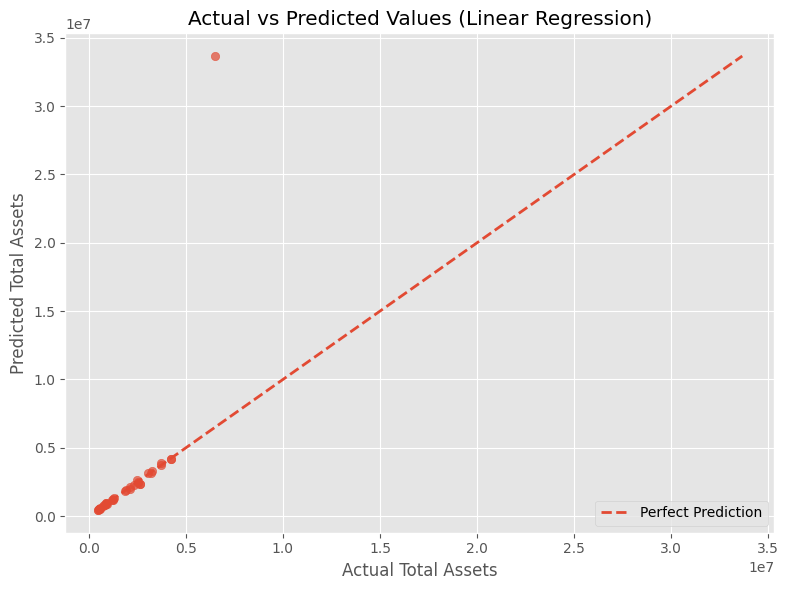

In [84]:
# ============================================================
# Section 7.7: Actual vs Predicted Plot
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Create the figure
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test_reg,
    y_test_pred_reg,
    alpha=0.7
)

# Determine axis limits
min_value = min(y_test_reg.min(), y_test_pred_reg.min())
max_value = max(y_test_reg.max(), y_test_pred_reg.max())

# Plot the ideal prediction line
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

# Labels and title
plt.xlabel("Actual Total Assets")
plt.ylabel("Predicted Total Assets")
plt.title("Actual vs Predicted Values (Linear Regression)")

# Add legend
plt.legend()

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

### Interpretation

The scatter plot compares the actual Total Assets with the values predicted by the Linear Regression model.

The dashed diagonal line represents **perfect prediction**, where the predicted value is exactly equal to the actual value.

When interpreting the figure:

- Points close to the diagonal line indicate accurate predictions.
- Points above the line indicate that the model has overestimated Total Assets.
- Points below the line indicate that the model has underestimated Total Assets.
- A random distribution of points around the reference line suggests that the model captures the underlying relationship reasonably well.
- Large deviations from the line may indicate prediction errors, influential observations, or nonlinear relationships that cannot be adequately modeled by Linear Regression.

This visualization complements the numerical evaluation metrics presented in the previous section and provides an intuitive assessment of the model's predictive capability.

### Transition

While the Actual vs Predicted plot evaluates the overall agreement between observed and predicted values, it does not reveal whether the prediction errors exhibit systematic patterns.

The next section examines the residuals (prediction errors) to determine whether the assumptions of Linear Regression are reasonably satisfied and to identify potential issues such as heteroscedasticity, model bias, or influential observations.

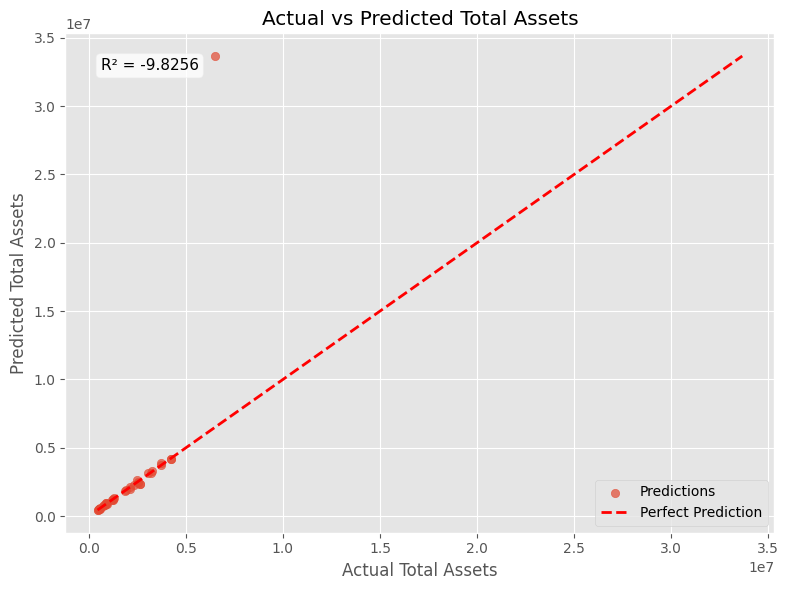

In [85]:
# ============================================================
# Section 7.7: Actual vs Predicted Plot
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    y_test_reg,
    y_test_pred_reg,
    alpha=0.7,
    label="Predictions"
)

# Perfect prediction line
min_val = min(y_test_reg.min(), y_test_pred_reg.min())
max_val = max(y_test_reg.max(), y_test_pred_reg.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Total Assets")
plt.ylabel("Predicted Total Assets")
plt.title("Actual vs Predicted Total Assets")

# Display R²
plt.text(
    0.05,
    0.95,
    f"R² = {r2_test:.4f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
print(X_reg.columns.tolist())

['AD01_010 | Income distributed to IAH', 'AD01_020 | Total income from assets funded by PSIA', 'AD02_010 | Off-balance sheet items', 'AD03_010 | FX funding ', 'AD03_020 | Total funding', 'AD04_010 | FX financing', 'AD04_020 | Total financing', 'AD05_010 | Sukūk holdings', 'AD05_020 | Total regulatory capital', 'AD06_010 | Value of Sharī`ah-compliant financing', 'AD06_010_010_010 | (a) agriculture, forestry, hunting and fishing', 'AD06_010_010_0110 | (i)accommodation and food service activities', 'AD06_010_010_0130 | (j)information and communication', 'AD06_010_010_0140 | (k) financial and insurance activities ', 'AD06_010_010_0150 | (l)real estate activities', 'AD06_010_010_0170 | (m)  professional, scientific and technical activities', 'AD06_010_010_0180 | (n) administrative and support service activities', 'AD06_010_010_0190 | (o) public administration and defense; compulsory social security', 'AD06_010_010_020 | (b) mining and quarrying', 'AD06_010_010_0210 | (p) education', 'AD06_0

In [87]:
[col for col in df_model.columns if "Total assets" in col]

['AD02_020 | Total assets',
 'CP11_020 | Total assets',
 'CP13_020 | Total assets',
 'ST03 | Total assets ']

In [88]:
for col in df_model.columns:
    print(repr(col))

'Country'
'Report Type'
'Year'
'Quarter'
'Year_Quarter'
'AD01_010 | Income distributed to IAH'
'AD01_020 | Total income from assets funded by PSIA'
'AD02_010 | Off-balance sheet items'
'AD02_020 | Total assets'
'AD03_010 | FX funding '
'AD03_020 | Total funding'
'AD04_010 | FX financing'
'AD04_020 | Total financing'
'AD05_010 | Sukūk holdings'
'AD05_020 | Total regulatory capital'
'AD06_010 | Value of Sharī`ah-compliant financing'
'AD06_010_010_010 | (a) agriculture, forestry, hunting and fishing'
'AD06_010_010_0110 | (i)accommodation and food service activities'
'AD06_010_010_0130 | (j)information and communication'
'AD06_010_010_0140 | (k) financial and insurance activities '
'AD06_010_010_0150 | (l)real estate activities'
'AD06_010_010_0170 | (m)  professional, scientific and technical activities'
'AD06_010_010_0180 | (n) administrative and support service activities'
'AD06_010_010_0190 | (o) public administration and defense; compulsory social security'
'AD06_010_010_020 | (b) mini

In [89]:
df_model.columns = df_model.columns.str.strip()

In [90]:
target_regression = "Total assets"

In [91]:
[col for col in X_reg.columns if "Total assets" in col]

['ST03 | Total assets ']

In [92]:
[col for col in df_model.columns if "Total assets" in col]

['AD02_020 | Total assets',
 'CP11_020 | Total assets',
 'CP13_020 | Total assets',
 'ST03 | Total assets']

In [93]:
df_model.columns[df_model.columns.duplicated()]

Index([], dtype='object')

In [94]:
# ============================================================
# Inspect Duplicate Columns
# ============================================================

duplicate_cols = df_model.columns[df_model.columns.duplicated()].unique()

for col in duplicate_cols:
    print("=" * 60)
    print(f"Column: {col}")

    duplicated_data = df_model.loc[:, df_model.columns == col]

    print(f"Number of Copies: {duplicated_data.shape[1]}")

    if duplicated_data.shape[1] == 2:
        print("Identical Values:",
              duplicated_data.iloc[:, 0].equals(duplicated_data.iloc[:, 1]))

    display(duplicated_data.head())

In [95]:
duplicate_cols = df_model.columns[df_model.columns.duplicated()].unique()

for col in duplicate_cols:
    print("\n" + "="*80)
    print(col)

    display(df_model.loc[:, df_model.columns == col].describe().T)

In [96]:
# Display duplicate columns side by side

duplicates = ["Murābahah", "Others", "Total assets", "Total financing"]

for col in duplicates:

    print("\n", "="*90)
    print(col)

    display(df_model.loc[:, df_model.columns == col].head(10))


Murābahah


""
0
1
2
3
4
5
6
7
8
9



Others


""
0
1
2
3
4
5
6
7
8
9



Total assets


""
0
1
2
3
4
5
6
7
8
9



Total financing


""
0
1
2
3
4
5
6
7
8
9


In [97]:
ta = df_model.loc[:, df_model.columns == "Total assets"]
print(ta.iloc[:, 0].equals(ta.iloc[:, 1]))

tf = df_model.loc[:, df_model.columns == "Total financing"]
print(tf.iloc[:, 0].equals(tf.iloc[:, 1]))

IndexError: single positional indexer is out-of-bounds